# ROAD SHIT
* malek jeet

In [1]:
#imports

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import entropy, shapiro
import scipy.stats as stats
import time
import seaborn as sns

# evaluation measures
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import PrecisionRecallDisplay

# scalers
from sklearn.preprocessing import StandardScaler

# Algorithms

from sklearn.svm import LinearSVC # SVC impractial with over 10000 samples
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

<function matplotlib.pyplot.show(close=None, block=None)>

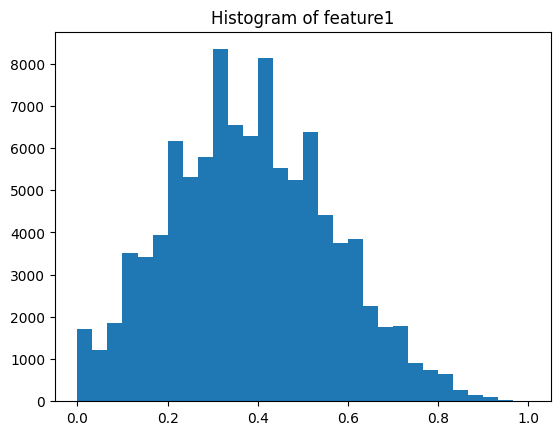

In [ ]:
data = pd.read_csv("synthetic_road_accidents_100k.csv", sep=",")
# data.head(5)

# plt.hist(data["accident_risk"], bins=30)
# plt.title("Histogram of feature1")
# plt.show

# stats.probplot(data["accident_risk"], dist="norm", plot=plt)
# plt.title("Q-Q Plot of feature1")
# plt.show()

# stat, p = shapiro(data["accident_risk"])
# print("Shapiro-Wilk p-value for feature1:", p)

In [49]:
print("roadtype",data["road_type"].unique(),"\n")
print("num_lanes",data["num_lanes"].unique(),"\n")
print("curvature",data["curvature"].unique(),"\n")
print("speed_limit",data["speed_limit"].unique(),"\n")
print("lighting",data["lighting"].unique(),"\n")
print("weather",data["weather"].unique(),"\n")
print("road_signs_present",data["road_signs_present"].unique(),"\n")
print("public_road",data["public_road"].unique(),"\n")
print("time_of_day",data["time_of_day"].unique(),"\n")
print("holiday",data["holiday"].unique(),"\n")
print("school_season",data["school_season"].unique(),"\n")
print("num_reported_accidents",data["num_reported_accidents"].unique(),"\n")
print("accident_risk",data["accident_risk"].unique(),"\n")

roadtype ['rural' 'highway' 'urban'] 

num_lanes [2 1 3 4] 

curvature [0.29 0.34 0.76 0.37 0.39 0.52 0.06 0.72 0.09 0.89 0.54 0.94 0.4  0.98
 0.61 0.12 0.56 0.05 0.44 0.67 0.13 0.16 0.27 0.85 0.55 0.96 0.62 0.08
 0.41 0.73 0.25 0.02 0.99 0.47 0.03 0.45 0.01 0.14 0.35 0.49 0.48 0.93
 0.53 0.43 0.15 0.38 0.33 0.95 0.31 0.23 0.75 0.88 0.36 0.7  0.26 0.32
 0.3  0.1  0.42 0.84 0.46 0.58 0.74 0.24 0.91 0.71 0.17 0.59 0.07 0.2
 0.77 0.57 0.66 0.28 0.22 0.11 0.63 0.83 0.9  0.6  0.97 0.19 0.8  0.04
 0.65 0.18 0.68 0.81 0.51 0.86 0.69 0.64 0.87 0.79 1.   0.5  0.78 0.21
 0.   0.82 0.92] 

speed_limit [70 25 45 60 35] 

lighting ['night' 'dim' 'daylight'] 

weather ['rainy' 'clear' 'foggy'] 

road_signs_present [False  True] 

public_road [ True False] 

time_of_day ['evening' 'morning' 'afternoon'] 

holiday [False  True] 

school_season [False  True] 

num_reported_accidents [ 1  3  0  2  6  5  4  8  7 10  9] 

accident_risk [0.64 0.27 0.76 0.6  0.17 0.59 0.03 0.38 0.51 0.24 0.49 0.08 0.63 0.1


In [38]:
print(f"Total instances: {data.shape[0]}, Total Attributes: {data.shape[1]}\n")

class0 = (data.iloc[:, 0] == 'rural').sum()
class1 = (data.iloc[:, 0]  == 'highway').sum()
class2 = (data.iloc[:, 0]  == 'urban').sum()
# class3 = (data["road_type"] == 3).sum()
class0_percentage = (class0 / data.shape[0] * 100)
class1_percentage = (class1 / data.shape[0] * 100)
class2_percentage = (class2 / data.shape[0] * 100)
# class3_percentage = (class3 / data.shape[0] * 100)


print(f"Class 0 (benign URLs) samples: {class0}      | Class 0 %: {(class0_percentage):.3}%\n"
      f"Class 1 (defacement URLs) samples: {class1}   | Class 1 %: {(class1_percentage):.3}%\n"
      f"Class 2 (phishing URLs) samples: {class2}     | Class 2 %: {(class2_percentage):.3}%\n")
      # f"Class 3 (malware URLs) samples: {class3}      | Class 3 %: {(class3_percentage):.3}%\n")

Total instances: 100000, Total Attributes: 13

Class 0 (benign URLs) samples: 33127      | Class 0 %: 33.1%
Class 1 (defacement URLs) samples: 33424   | Class 1 %: 33.4%
Class 2 (phishing URLs) samples: 33449     | Class 2 %: 33.4%



In [47]:
print(data["road_type"].describe(),"\n")
print(data["num_lanes"].describe(),"\n")
print(data["curvature"].describe(),"\n")
print(data["speed_limit"].describe(),"\n")
print(data["lighting"].describe(),"\n")
print(data["weather"].describe(),"\n")
print(data["road_signs_present"].describe(),"\n")
print(data["public_road"].describe(),"\n")
print(data["time_of_day"].describe(),"\n")
print(data["holiday"].describe(),"\n")
print(data["school_season"].describe(),"\n")
print(data["num_reported_accidents"].describe(),"\n")
print(data["accident_risk"].describe(),"\n")

count     100000
unique         3
top        urban
freq       33449
Name: road_type, dtype: object 

count    100000.000000
mean          2.495300
std           1.117958
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max           4.000000
Name: num_lanes, dtype: float64 

count    100000.000000
mean          0.500619
std           0.288691
min           0.000000
25%           0.250000
50%           0.500000
75%           0.750000
max           1.000000
Name: curvature, dtype: float64 

count    100000.000000
mean         47.054550
std          16.321527
min          25.000000
25%          35.000000
50%          45.000000
75%          60.000000
max          70.000000
Name: speed_limit, dtype: float64 

count     100000
unique         3
top          dim
freq       33562
Name: lighting, dtype: object 

count     100000
unique         3
top        clear
freq       33511
Name: weather, dtype: object 

count     100000
unique         2
top       

In [ ]:
col = 'url_len'
Q1 = data[col].quantile(0.25)
Q3 = data[col].quantile(0.75)
IQR = Q3 - Q1
outliers_url_len = data[(data[col] < (Q1 - 1.5 * IQR)) | (data[col] > (Q3 + 1.5 * IQR))]
print(f"Outliers in '{col}': {outliers_url_len.shape[0]}")

col = 'letters'
Q1 = data[col].quantile(0.25)
Q3 = data[col].quantile(0.75)
IQR = Q3 - Q1
outliers_letters = data[(data[col] < (Q1 - 1.5 * IQR)) | (data[col] > (Q3 + 1.5 * IQR))]
print(f"Outliers in '{col}': {outliers_letters.shape[0]}")